# New Section

In [1]:
#import file
#!git clone https://github.com/EllaN12/Restaurant-Ratings.git

In [2]:
#!git add .
#!git commit -m "update notebook"
#!git push -u origin main


In [3]:
import sys
import os
#sys.path.append('/content/Restaurant-Ratings')
#os.chdir('/content/Restaurant-Ratings')

In [7]:
#pip install -r '/content/Restaurant-Ratings/requirements.txt'
import os
os.chdir('/Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/causal')

**Note:** **This notebook demonstrates the application of the DoWhy library for causal analysis. Certain functions are imported as modules. For a detailed examination of these functions, please consult the source code files located in the 'src' directory on GitHub**.


In [8]:
# Import dataset (refer to analysis.py module for details of data pre-processing )
from causal_analysis_module.analysis import data_preprocessing


df = data_preprocessing ()
print (df.head())





Successfully loaded: chefmozparking with shape (702, 2)
Successfully loaded: chefmozaccepts with shape (1314, 2)
Successfully loaded: userpayment with shape (177, 2)
Successfully loaded: geoplaces2 with shape (130, 21)
Successfully loaded: rating_final with shape (1161, 5)
Successfully loaded: usercuisine with shape (330, 2)
Successfully loaded: chefmozcuisine with shape (916, 2)
Successfully loaded: chefmozhours4 with shape (2339, 3)
Successfully loaded: userprofile with shape (138, 19)
Error loading *: [Errno 21] Is a directory: '/Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/causal/00_Raw_Data/*.csv'

Available dataframes:
- chefmozparking
- chefmozaccepts
- userpayment
- geoplaces2
- rating_final
- usercuisine
- chefmozcuisine
- chefmozhours4
- userprofile
   p.latitude  p.longitude  birth_year  ...  location_cluster  age  age_group
0   22.139997  -100.978803        1989  ...                 3   36      36-50
1   22.139997  -100.978803        1989  ...              

#Create Causal Graph

I conducted EDA and found high correlations among several variables (refer to data_report.html ). Using these correlations and considering potential causal effects, I created the causal graph specification below: 


In [9]:
# Create grapgh specifications
def create_causal_graph_spec():
    """
    Create the causal graph specification for DoWhy
    """
    graph = """
    digraph {
        # Direct Effects on Rating
        food_rating -> rating;
        service_rating -> rating;
        age_group -> rating;
        activity -> rating;
        personality -> rating;
        User_cuisine -> rating;
        
        # Demographic Effects
        age_group -> budget;
        age_group -> User_cuisine;
        age_group -> drink_level;
        age_group -> dress_preference;
        
        activity -> budget;
        activity -> transport;
        
        marital_status -> hijos;
        marital_status -> budget;
        marital_status -> user_ambience;
        
        # Restaurant Selection Effects
        transport -> accessibility;
        transport -> area;
        budget -> price;
        cuisine_match_score -> food_rating
        patrons_restaurant_distance -> transport
        
        # Personal Attribute Effects
        weight -> food_rating;
        personality -> food_rating;
        height -> food_rating;
        color -> food_rating;
        hijos -> food_rating;
        
        # Service Rating Influences
        color -> service_rating;
        personality -> service_rating;
        
        # Transport and Accessibility Chain
        transport -> smoker;
        transport -> dress_preference;
        transport -> weight;
    }
    """
    return graph

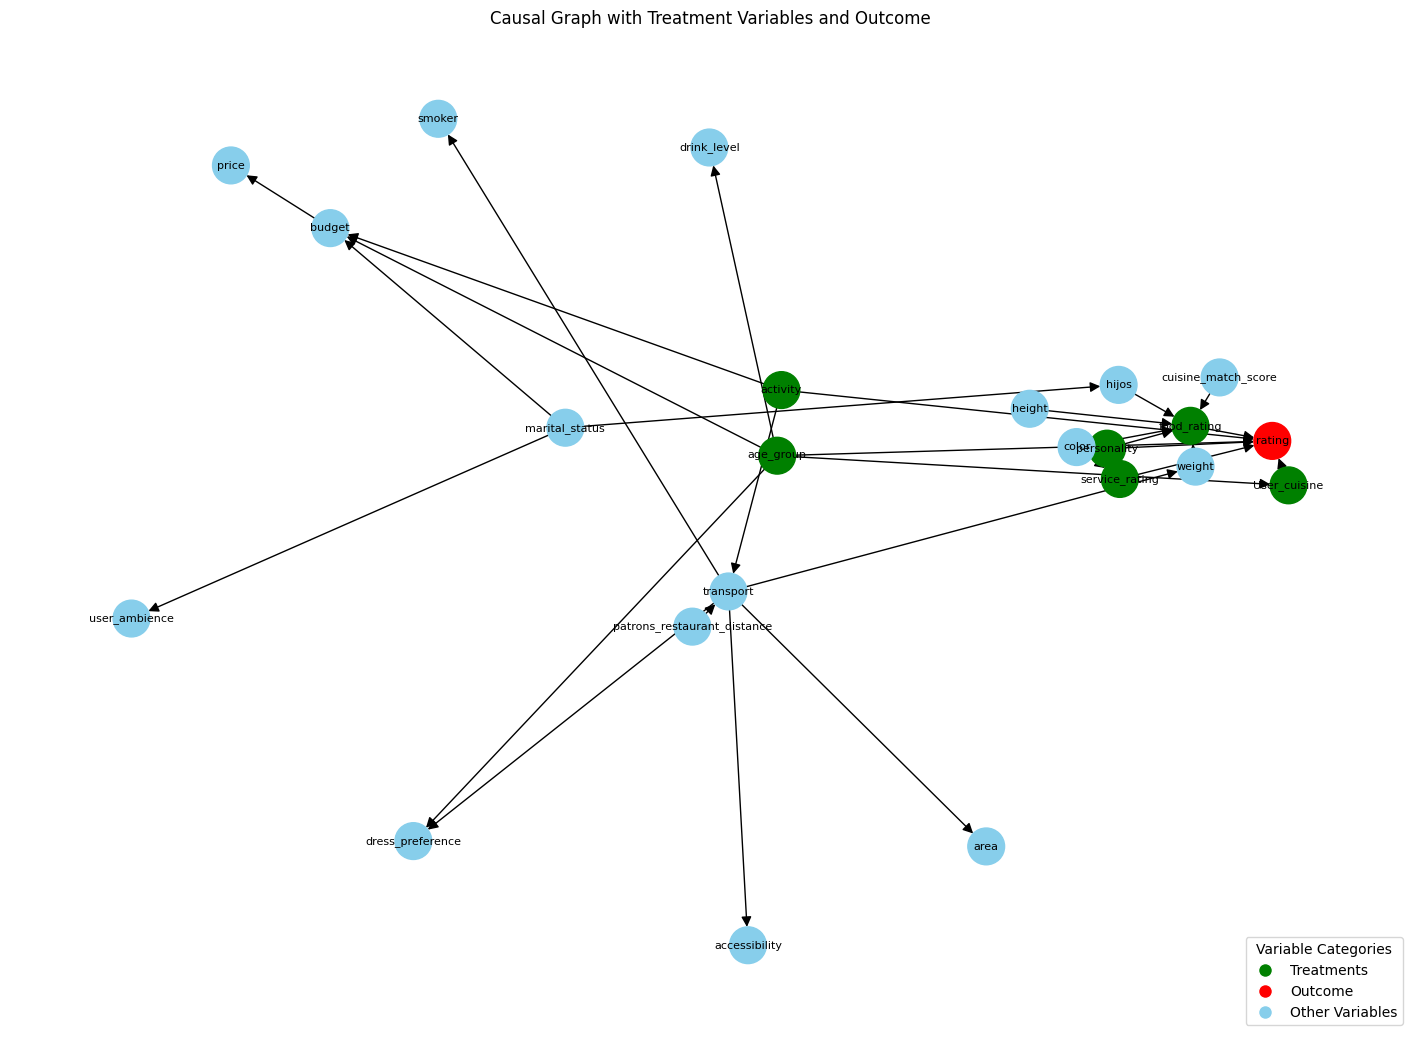

MultiDiGraph named 'G' with 23 nodes and 30 edges


In [10]:
# Causal Graph vizualization
from causal_analysis_module.causal_graph import create_and_visualize_graph, create_causal_graph_spec

print  (create_and_visualize_graph(graph_spec = create_causal_graph_spec()))

Through causal analysis, the following treatments were identified: ['food_rating', 'service_rating', 'age_group', 'activity', 'personality', 'User_cuisine']. These treatments serve as the foundation of the causal model. The treatment-specific causal analysis and corresponding results are presented below. For model specifications, please refer to the 'causal_analysis_module/causal_model.py' file

In [39]:
# Prepere data for causal analysis 
from causal_analysis_module.analysis import data_preprocessing
from causal_analysis_module.prepare_data import prepare_for_causal_analysis

treatment_lst = ['food_rating', 'service_rating', 'age_group', 'activity', 'personality', 'User_cuisine']


data_prep = prepare_for_causal_analysis(
    df = data_preprocessing(),
    treatment_vars= treatment_lst,
    outcome_var= 'rating'
)
print (data_prep['X_test'])


Successfully loaded: chefmozparking with shape (702, 2)
Successfully loaded: chefmozaccepts with shape (1314, 2)
Successfully loaded: userpayment with shape (177, 2)
Successfully loaded: geoplaces2 with shape (130, 21)
Successfully loaded: rating_final with shape (1161, 5)
Successfully loaded: usercuisine with shape (330, 2)
Successfully loaded: chefmozcuisine with shape (916, 2)
Successfully loaded: chefmozhours4 with shape (2339, 3)
Successfully loaded: userprofile with shape (138, 19)
Error loading *: [Errno 21] Is a directory: '/Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/causal/00_Raw_Data/*.csv'

Available dataframes:
- chefmozparking
- chefmozaccepts
- userpayment
- geoplaces2
- rating_final
- usercuisine
- chefmozcuisine
- chefmozhours4
- userprofile
Preparing data for causal analysis with CausalForestDML...
Treatments: ['food_rating', 'service_rating', 'age_group', 'activity', 'personality', 'User_cuisine']
Outcome: rating

Initial data examination:
Data shap

In [15]:
# Run the model
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from causal_analysis_module.analysis import data_preprocessing
#from causal_analysis_module.prepare_data import prepare_for_causal_analysis
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from econml.dml import CausalForestDML
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats



#create model
model  = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=100, max_depth=10),
    model_t=RandomForestRegressor(n_estimators=100, max_depth=10),
    criterion= "mse",
    n_estimators= 100,
    honest= True,
    inference= True
)


print (model)


In [16]:
#create causal model
from econml.dml import CausalForestDML 
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from causal_analysis_module.analysis import data_preprocessing
from causal_analysis_module.prepare_data import prepare_for_causal_analysis
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from econml.dml import CausalForestDML
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

model  = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=100, max_depth=10),
    model_t=RandomForestRegressor(n_estimators=100, max_depth=10),
    criterion= "mse",
    n_estimators= 100,
    honest= True,
    inference= True
)




In [17]:
# Identify confounders
from causal_analysis_module.causal_model import identify_confounders, apply_confounder_filter_to_model
from causal_analysis_module.prepare_data import prepare_data_for_causalforest
apply_confounder_filter_to_model(
    X = data_prep['X'],
    Y = data_prep['Y'],
    T = data_prep['T'],
    feature_names = data_prep['feature_names']
)


    


Identified 446 total confounders
Found 4 strong confounders meeting all criteria:
  - color_purple: confounding_strength=0.5395, treatment_correlation=-0.7283, outcome_correlation=-0.7408
  - hijos_kids: confounding_strength=0.4838, treatment_correlation=-0.6891, outcome_correlation=-0.7021
  - hijos_independent: confounding_strength=0.4382, treatment_correlation=0.6598, outcome_correlation=0.6641
  - budget_low: confounding_strength=0.4147, treatment_correlation=-0.6529, outcome_correlation=-0.6352
Using first dimension from 6-dimensional treatment


{'model': <econml.dml.causal_forest.CausalForestDML at 0x309948620>,
 'treatment_effects': array([0.93349204, 0.4550674 , 0.7877139 , ..., 0.66440622, 0.49576096,
        0.55697822]),
 'confidence_intervals': (array([ 0.72654334, -0.08129335,  0.53479416, ...,  0.47746049,
          0.13260319,  0.01094081]),
  array([1.14044073, 0.99142815, 1.04063365, ..., 0.85135195, 0.85891872,
         1.10301563])),
 'strong_confounders': [{'feature': 'color_purple',
   'treatment_correlation': -0.7283279483696168,
   'treatment_pvalue': 0.0,
   'outcome_correlation': -0.7407691817941326,
   'outcome_pvalue': 0.0,
   'confounding_strength': 0.5395228983915603,
   'index': 33},
  {'feature': 'hijos_kids',
   'treatment_correlation': -0.6891124741564338,
   'treatment_pvalue': 0.0,
   'outcome_correlation': -0.7020942902099663,
   'outcome_pvalue': 0.0,
   'confounding_strength': 0.48382193341769514,
   'index': 21},
  {'feature': 'hijos_independent',
   'treatment_correlation': 0.6598211750348529

In [18]:
# fit the model
from econml.dml import CausalForestDML 
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from causal_analysis_module.analysis import data_preprocessing
from causal_analysis_module.prepare_data import prepare_for_causal_analysis
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from econml.dml import CausalForestDML
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

treatment_lst = ['food_rating', 'service_rating', 'age_group', 'activity', 'personality', 'User_cuisine']

data_prep = prepare_for_causal_analysis(
    df = data_preprocessing(),
    treatment_vars= treatment_lst,
    outcome_var= 'rating'
)

model.fit(
    Y= data_prep['Y_train'],
    T= data_prep['T_train'],
    X= data_prep['X_train'],
    W= None
)


Successfully loaded: chefmozparking with shape (702, 2)
Successfully loaded: chefmozaccepts with shape (1314, 2)
Successfully loaded: userpayment with shape (177, 2)
Successfully loaded: geoplaces2 with shape (130, 21)
Successfully loaded: rating_final with shape (1161, 5)
Successfully loaded: usercuisine with shape (330, 2)
Successfully loaded: chefmozcuisine with shape (916, 2)
Successfully loaded: chefmozhours4 with shape (2339, 3)
Successfully loaded: userprofile with shape (138, 19)
Error loading *: [Errno 21] Is a directory: '/Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/causal/00_Raw_Data/*.csv'

Available dataframes:
- chefmozparking
- chefmozaccepts
- userpayment
- geoplaces2
- rating_final
- usercuisine
- chefmozcuisine
- chefmozhours4
- userprofile
Preparing data for causal analysis with CausalForestDML...
Treatments: ['food_rating', 'service_rating', 'age_group', 'activity', 'personality', 'User_cuisine']
Outcome: rating

Initial data examination:
Data shap

                                    Feature  Importance
4               patrons_restaurant_distance    0.190555
31                              color_green    0.161036
2                                  latitude    0.103415
23                           interest_retro    0.086393
548                      hours_08:00-23:00;    0.055680
1                                    height    0.042060
0                                    weight    0.024047
657                       end_time_22:00:00    0.022801
251  restaurant_name_Restaurante la Cantina    0.019475
8                   dress_preference_formal    0.013621


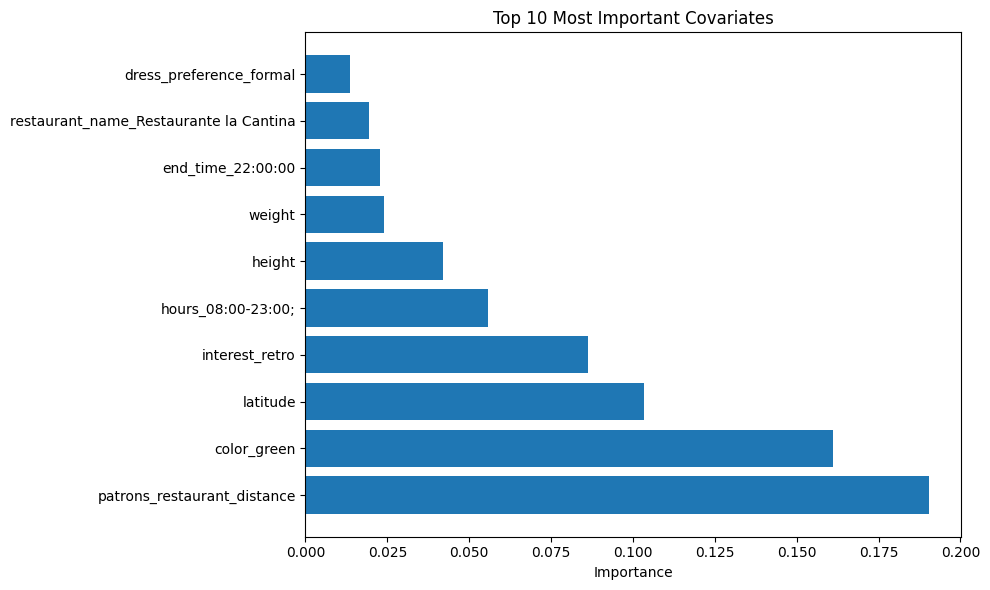

In [19]:
# Determine Feature importance
from causal_analysis_module.causal_model import treatment_effect_dataframe

feature_importances = model.feature_importances_

# Create and vizualise a DataFrame with feature names and importances
feature_df = pd.DataFrame({
    'Feature': data_prep['feature_names'],
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print(feature_df.head(10))  # Top 10 most important features

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feature_df['Feature'][:10], feature_df['Importance'][:10])
plt.xlabel('Importance')
plt.title('Top 10 Most Important Covariates')
plt.tight_layout()
plt.show()


In [20]:
# Estimate Treatment Effects assuming 95% confidence interval

treatment_effects  = model.effect(data_prep['X_test'])
lb, ub = model.effect_interval(data_prep['X_test'], alpha= 0.05)

print (treatment_effects)

[-0.1125093  -0.69443095 -0.2915949  ...  0.44729074  0.30190872
  0.71231831]


In [21]:
# Analyse the treatment effect for treatment model for Food rating
from causal_analysis_module.causal_model import treatment_effect_dataframe
from causal_analysis_module.prepare_data import prepare_for_causal_analysis

treatment_lst = ['food_rating', 'service_rating', 'age_group', 'activity', 'personality', 'User_cuisine']
#outcome_var = 'rating'

data_prep = prepare_for_causal_analysis(  
 df = data_preprocessing(),
    treatment_vars = treatment_lst , outcome_var = 'rating' )


# treatment effect 
treatment_effects  = model.effect(data_prep['X_test'])
lb, ub = model.effect_interval(data_prep['X_test'], alpha= 0.05)




Successfully loaded: chefmozparking with shape (702, 2)
Successfully loaded: chefmozaccepts with shape (1314, 2)
Successfully loaded: userpayment with shape (177, 2)
Successfully loaded: geoplaces2 with shape (130, 21)
Successfully loaded: rating_final with shape (1161, 5)
Successfully loaded: usercuisine with shape (330, 2)
Successfully loaded: chefmozcuisine with shape (916, 2)
Successfully loaded: chefmozhours4 with shape (2339, 3)
Successfully loaded: userprofile with shape (138, 19)
Error loading *: [Errno 21] Is a directory: '/Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/causal/00_Raw_Data/*.csv'

Available dataframes:
- chefmozparking
- chefmozaccepts
- userpayment
- geoplaces2
- rating_final
- usercuisine
- chefmozcuisine
- chefmozhours4
- userprofile
Preparing data for causal analysis with CausalForestDML...
Treatments: ['food_rating', 'service_rating', 'age_group', 'activity', 'personality', 'User_cuisine']
Outcome: rating

Initial data examination:
Data shap

In [22]:
#All treatments
from causal_analysis_module.causal_model import treatment_effect_dataframe
treatment_lst = ['food_rating', 'service_rating', 'age_group', 'activity', 'personality', 'User_cuisine']

causal_analysis = treatment_effect_dataframe(
    treatment_effects = treatment_effects,
    treatment_name= treatment_lst,
    data_prep= data_prep
)
effects_df = causal_analysis
print (effects_df)

      treatment_effect      treatment_name  ...  effect_magnitude    effect_category
0            -0.112509  combined_treatment  ...          0.112509  Moderate Negative
1            -0.694431  combined_treatment  ...          0.694431    Strong Negative
2            -0.291595  combined_treatment  ...          0.291595  Moderate Negative
3             0.154621  combined_treatment  ...          0.154621  Moderate Positive
4             0.128181  combined_treatment  ...          0.128181  Moderate Positive
...                ...                 ...  ...               ...                ...
6307          2.114102  combined_treatment  ...          2.114102    Strong Positive
6308          0.607826  combined_treatment  ...          0.607826    Strong Positive
6309          0.447291  combined_treatment  ...          0.447291  Moderate Positive
6310          0.301909  combined_treatment  ...          0.301909  Moderate Positive
6311          0.712318  combined_treatment  ...          0.712318

In [28]:
# Count of effect categories

effect_category_counts = effects_df['effect_category'].value_counts().reset_index()
effect_category_counts.columns = ['effect_category', 'count']
effect_summary_df = effect_category_counts
print(effect_summary_df)




     effect_category  count
0    Strong Positive   2510
1    Strong Negative   1607
2  Moderate Positive   1201
3  Moderate Negative    633
4         Negligible    361


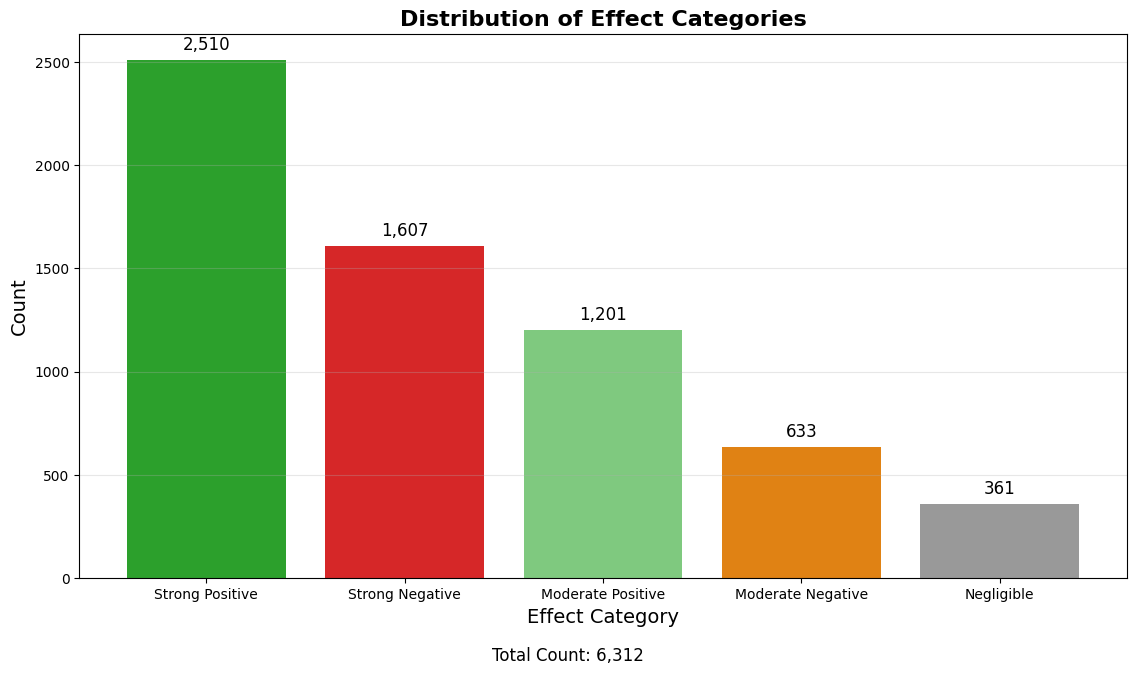

None


In [ ]:
def effect_graph():
    effect_category_counts = effects_df['effect_category'].value_counts().reset_index()
    effect_category_counts.columns = ['effect_category', 'count']
    df = effect_category_counts
    # Sort data by count in descending order for better visualization
    df = df.sort_values('count', ascending=False)

    # Create a colormap based on the effect categories
    colors = ['#2ca02c', '#d62728', '#7fc97f', '#e08214', '#999999']  # green, red, light green, orange, gray
    # Create the bar plot
    plt.figure(figsize=(12, 7))
    bars = plt.bar(df['effect_category'], df['count'], color=colors)

    # Add count values on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 50,
                f'{height:,}', ha='center', fontsize=12)

        # Add labels and title
    plt.xlabel('Effect Category', fontsize=14)
    plt.ylabel('Count', fontsize=14)
    plt.title('Distribution of Effect Categories', fontsize=16, fontweight='bold')

    # Add grid lines for better readability
    plt.grid(axis='y', alpha=0.3)

    # Add total count in the figure
    total_count = df['count'].sum()
    plt.figtext(0.5, 0.01, f'Total Count: {total_count:,}', ha='center', fontsize=12)

        # Improve layout
    plt.tight_layout(pad=3)

    # Display the plot
    plt.show()


print(effect_graph())

In [45]:
# Treatment effect function
treatment_effects  = model.effect(data_prep['X_test'])
lb, ub = model.effect_interval(data_prep['X_test'], alpha= 0.05)




IndexError: invalid index to scalar variable.

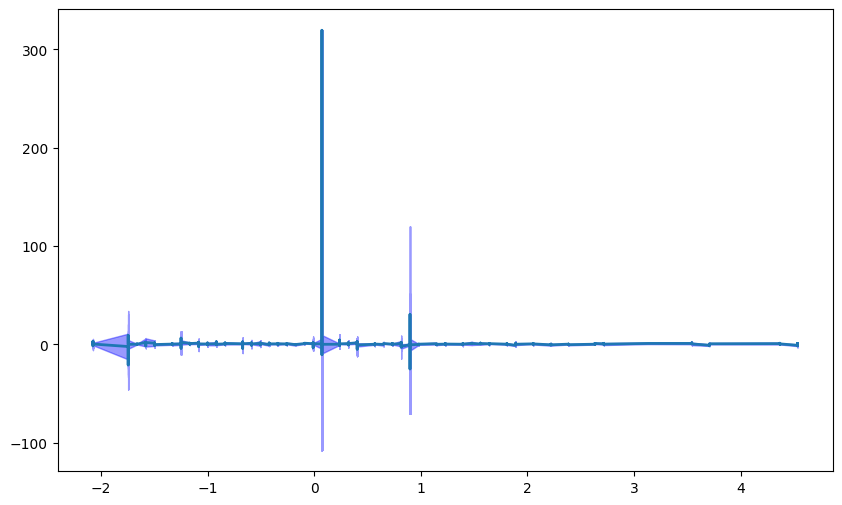

In [ ]:
def plot_single_treatment(data_prep, treatment_effects, lb, treatment_idx=0, treatment_name=None):
    """
    Plot the treatment effect for a single treatment without interactive controls.
    """

    def true_relationship(x):
        return np.exp(2*x[0])

    plt.figure(figsize=(10, 6))
    
    # Extract data for the selected treatment
    x_values = data_prep['X_test'][:, treatment_idx]
    sorted_indices = np.argsort(x_values)
    x_sorted = x_values[sorted_indices]
    effects_sorted = treatment_effects[sorted_indices]
    lb_sorted = lb[sorted_indices]
    ub_sorted = ub[sorted_indices]
    
    # Plot the double ML results
    plt.plot(x_sorted, effects_sorted, label='Non-parametric double ML', linewidth=2)
    plt.fill_between(x_sorted, lb_sorted, ub_sorted, alpha=.4, color='blue')
    
    # Plot ground truth if provided
    if true_relationship:
        ground_truth = np.array([true_relationship(x_i) for x_i in x_sorted])
        plt.plot(x_sorted, ground_truth, '--', label='True effect', c='black', linewidth=2)
    
    plt.ylabel('Outcome (Effect)', fontsize=12)
    plt.xlabel('Treatment Value (Cause)', fontsize=12)
    
    if treatment_name:
        plt.title(f'Treatment Effect: {treatment_name}', fontsize=14, fontweight='bold')
    else:
        plt.title(f'Treatment Effect: Treatment {treatment_idx+1}', fontsize=14, fontweight='bold')
        
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_single_treatment(data_prep = data_prep,
    treatment_effects = treatment_effects,
    lb = lb, 
     #treatment_idx = 0,
      treatment_name = 'food_rating' )

In [33]:
# calculate the Average treatment Effect
ate = np.mean(treatment_effects)

# Calculate other summary statistics
median_effect = np.median(treatment_effects)
std_effect = np.std(treatment_effects)
min_effect = np.min(treatment_effects)
max_effect = np.max(treatment_effects)
positive_pct = (treatment_effects > 0).mean() * 100  # Percentage of positive effects

# Print the results
print(f"Average Treatment Effect (ATE): {ate:.4f}")
print(f"Median effect: {median_effect:.4f}")
print(f"Standard deviation: {std_effect:.4f}")
print(f"Min effect: {min_effect:.4f}")
print(f"Max effect: {max_effect:.4f}")
print(f"Percentage of positive effects: {positive_pct:.2f}%")

Average Treatment Effect (ATE): 2.3732
Median effect: 0.2873
Standard deviation: 21.9819
Min effect: -24.8984
Max effect: 319.5037
Percentage of positive effects: 62.55%


In [54]:
treatment_lst = ['food_rating', 'service_rating', 'age_group', 'activity', 'personality', 'User_cuisine']

causal_analysis = treatment_effect_dataframe(
    treatment_effects = treatment_effects,
    treatment_name=  'service_rating',
    data_prep= data_prep
)
effects_df = causal_analysis
print (effects_df)

      treatment_effect  treatment_name  outcome  positive_effect  \
0            -0.535557               2        2            False   
1             0.961895               1        1             True   
2             3.326681               0        0             True   
3             1.194651               1        2             True   
4             0.317204               1        1             True   
...                ...             ...      ...              ...   
6307         -0.978354               0        0            False   
6308         -0.295482               0        0            False   
6309         -0.162598               0        0            False   
6310          0.676258               1        1             True   
6311         -0.100041               1        2            False   

      effect_magnitude    effect_category  
0             0.535557    Strong Negative  
1             0.961895    Strong Positive  
2             3.326681    Strong Positive  
3      

In [55]:

# Count of effect categories
print("\nEffect Categories:")
print(effects_df['effect_category'].value_counts())


Effect Categories:
effect_category
Strong Positive      2438
Strong Negative      1679
Moderate Positive    1026
Moderate Negative     681
Negligible            488
Name: count, dtype: int64


Categories sorted by count (descending):
Moderate Positive: 2,438 (38.6%)
Strong Negative: 1,679 (26.6%)
Strong Positive: 1,026 (16.3%)
Strong Positive: 681 (10.8%)
Strong Positive: 488 (7.7%)


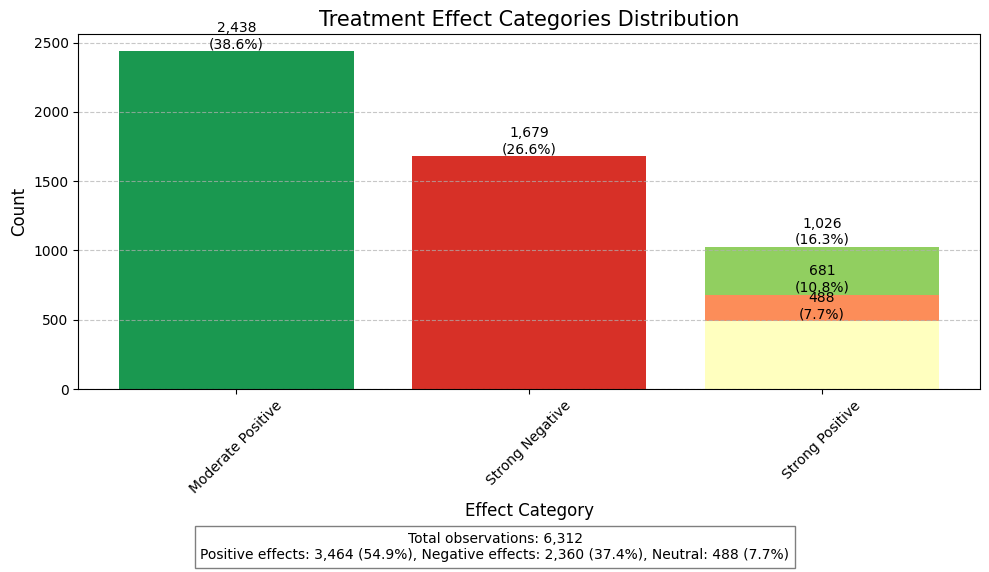